Goal: make an object that can take in a set of coordinates and then return euclid data/maps, rubin data/maps, and merged catalog

In [1]:
import sys
import os

#Goes up two directories to get the updated astroquery
#I really need to fix this, maybe github submodules or enforcing a version of astroquery
#I think it's version 0.4.11 ?
sys.path.append(os.path.abspath('../..'))
from astroquery_updated.esa.euclid import Euclid

from astropy import units as u
from astropy.coordinates import SkyCoord
import lsst.geom as geom
from lsst.daf.butler import Butler
from astropy.table import Table, vstack, join
import numpy as np
import gc
import warnings
import matplotlib.pyplot as plt
import healsparse as hsp
import skyproj
import lsst.analysis.tools
from pathlib import Path


warnings.filterwarnings('ignore')

In [2]:
sys.path.append(os.path.abspath('..'))
from config_file import *

Tract class goes from tract index --> coordinates  
Coordinate class attempts to go from coordinate --> tract and patch info  
However, the border/overlap regions are providing some difficulty

## Rubin Query

In [3]:
butler = Butler(repo, collections=collection)
SkyMap =  butler.get('skyMap',
                     skymap=skymap,
                     collections=collection)

In [5]:
class Tract():
    def __init__(self, tract, SkyMap):
        '''
        tract = int
        SkyMap = skyMap object, generated from butler
        '''
        self.tract = tract
        self.center = SkyCoord(SkyMap.generateTract(tract).getCtrCoord().getRa().asDegrees()*u.deg, 
                               SkyMap.generateTract(tract).getCtrCoord().getDec().asDegrees()*u.deg, 
                               frame='icrs')
        self.center_SpherePoint = SkyMap.generateTract(tract).getCtrCoord()
        ras = [SkyMap.getRaDecRange(tract)[0].asDegrees()*u.deg, SkyMap.getRaDecRange(tract)[1].asDegrees()*u.deg]
        self.ra_range = ras
        decs = [SkyMap.getRaDecRange(tract)[2].asDegrees()*u.deg, SkyMap.getRaDecRange(tract)[3].asDegrees()*u.deg]
        self.dec_range = decs
        corners = [SkyCoord(ra,dec,frame='icrs') for ra in ras for dec in decs]
        self.corners = corners
        self.corners_Angle = SkyMap.getRaDecRange(tract)

    def rubin_query(self):
        full_tract = butler.get('object', 
                                dataId={'skymap': skymap, 'tract': tract}, 
                                collections=dp2_collection, parameters={"columns":INCOLS})
        return full_tract


59.26829268292682 -48.34710743801652


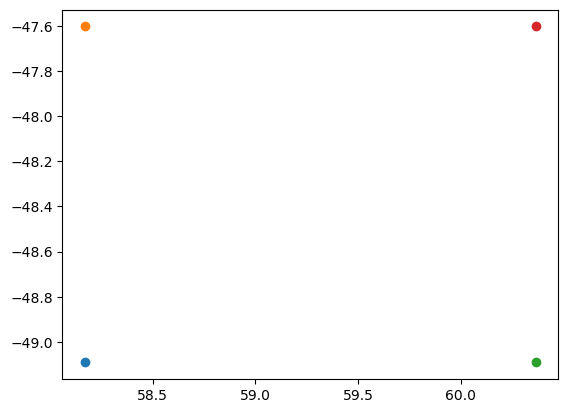

In [10]:
tract = Tract(2394, SkyMap)
ra = tract.center.ra.value
dec = tract.center.dec.value

print(ra,dec)

ra1,ra2 = tract.ra_range[0].value, tract.ra_range[1].value
dec1,dec2 = tract.dec_range[0].value, tract.dec_range[1].value

for point in tract.corners:
    plt.scatter(point.ra.deg, point.dec.deg)

In [ ]:
ra1

In [ ]:
ra, dec = 53.13, -28.1
radius = .5
query = '''
        SELECT right_ascension, declination, point_like_prob, point_like_flag,
        ellipticity, mumax_minus_mag, flux_vis_psf, fluxerr_vis_psf, spurious_flag,
        det_quality_flag, fwhm, segmentation_map_id
        '''
num = 2
for band in ['VIS', 'Y', 'J', 'H']:
    query += f", FLAG_{band}, FLUX_{band}_{num}FWHM_APER, FLUXERR_{band}_{num}FWHM_APER".lower()
query += f" FROM mer_catalogue WHERE DISTANCE({ra}, {dec}, right_ascension, declination) < {radius}"
#results_table = Euclid.cone_search(coordinate=coord, radius=1 * u.degree).get_results()#, columns = ['tileId'])

results_table = Euclid.launch_job_async(query, verbose=False).get_results()

print('ra: ', np.min(results_table['right_ascension']), np.max(results_table['right_ascension']))
print('dec: ', np.min(results_table['declination']), np.max(results_table['declination']))

In [ ]:
## rest of tract class

"""
    def euclid_query(self):
        '''
        returns results Table of a 1.7 deg circle around the center of tract coord 
        (which hopefully is big enough to capture the whole tract)
        '''
        
        # I don't know how big to make the Euclid query. I suppose big and then the merged catalog scales it down?
        # did the math and I think the dist from center to corner of tract is ~1.7 deg
        # assuming a patch is 13.7"
        radius = 1.7
        
        file_path = Path(my_path + f'/euclid_data/q1/{tract}_euclid_circle.parquet')
        
        if file_path.is_file():
            print('File exists.')
            results_table = Table.read(str(file_path))
        else:
            print('File not found. Querying now')
            query = '''
                    SELECT right_ascension, declination, point_like_prob, point_like_flag,
                    ellipticity, mumax_minus_mag, flux_vis_psf, fluxerr_vis_psf, spurious_flag,
                    det_quality_flag, fwhm, segmentation_map_id
                    '''
            num = 2
            for band in ['VIS', 'Y', 'J', 'H']:
                query += f", FLAG_{band}, FLUX_{band}_{num}FWHM_APER, FLUXERR_{band}_{num}FWHM_APER".lower()
            query += f" FROM mer_catalogue WHERE DISTANCE({ra}, {dec}, right_ascension, declination) < {radius}"
            #results_table = Euclid.cone_search(coordinate=coord, radius=1 * u.degree).get_results()#, columns = ['tileId'])
            
            results_table = Euclid.launch_job_async(query, verbose=False).get_results()
            results_table.write(my_path + f'/euclid_data/q1/{tract}_euclid_circle.parquet', 
                                   format='parquet', overwrite = True)
            print('File saved.')
            
        tile_ids = np.unique(results_table['segmentation_map_id'] // 10**6)  #from final catalog documentation
        self.euclid_tiles = tile_ids

        return results_table

    def merged_catalog(self):

        return table

    def euclid_maps(self, map_type):

        return euclid_healpix_map

    def rubin_maps(self, map_type):
        #look at this https://pipelines.lsst.io/py-api/lsst.analysis.tools.actions.plot.PerTractPropertyMapPlot.html

        return rubin_healsparse_map
"""

In [ ]:
#class Patch(Tract):
    #SkyMap.generateTract(2393).getPatchInfo(3)
    #look at findPatch(coord)
#^Find the patch containing the specified coord. Method of TractInfo
'''
dataset = 0
datasets = []
for i in range(len(tractPatchDictList)):
    tractpatchDict = tractPatchDictList[i]
    tract = tractpatchDict['tract']
    patch = tractpatchDict['patch']
    full_tract = butler.get('object', 
                            dataId={'skymap': skymap, 'tract': tract}, 
                            collections=collection, parameters={"columns":INCOLS})
    patch_restrict = full_tract[full_tract['patch']==patch]
    if ra <= np.max(patch_restrict['coord_ra']) and ra >= np.min(patch_restrict['coord_ra']):
        if dec <= np.max(patch_restrict['coord_dec']) and dec >= np.min(patch_restrict['coord_dec']):
            if dataset == 0:
                dataset = patch_restrict
            else:
                raise Exception('Multiple object catalogs found')
        else:
            datasets.append(patch_restrict)
    else:
        datasets.append(patch_restrict)
    del full_tract, patch_restrict
    gc.collect()
'''

### Euclid Maps

In [ ]:
map_name = 'q1.vmpz_healpix_coverage'
query = f"SELECT * FROM {map_name}"
results = Euclid.launch_job_async(query).get_results()
results.sort('file_path')
n = 1
start = 0
map_list = []
for i in range(start, start+8):
    #tileid = results['tile_index_list'][i][0]
    #print(tileid)
    try:
        map_list.append(hsp.HealSparseMap.read(f'euclid_data/{map_name[map_name.rfind('_')+1:]}_{tileid}_{n}.fits', nside_coverage=32))
    except:
        output_path = f"euclid_data/{map_name[map_name.rfind('_')+1:]}_{tileid}_{n}.fits"
        print(output_path)
        path = Euclid.get_product(file_name=results['file_name_list'][i], product_id = results['product_id'][i], 
                                  output_file=output_path, verbose=False)
        map_list.append(hsp.HealSparseMap.read(f'euclid_data/{map_name[map_name.rfind('_')+1:]}_{tileid}_{n}.fits', nside_coverage=32))
    n += 1

In [ ]:
fig, ax = plt.subplots(3,3,figsize=(14, 10))
for n in range(0,8):
    # ! need to figure out if this nside_coverage is telling hsp which coverage to read in 
        # or if it makes an assumption about the properties of this map
    sp = skyproj.MollweideSkyproj(ax=ax.flatten()[n])
    sp.draw_hspmap(map_list[n])
    sp.ax.set_xlabel("Right Ascension", fontsize = 7)
    sp.ax.set_ylabel("Declination", fontsize = 7)
    sp.ax.tick_params(axis = "x", labelsize=7)
    sp.ax.tick_params(axis = "y", labelsize=7)
plt.suptitle(f'Euclid Single Maps, Tile {tileid}', y=.9)
plt.colorbar(ax = ax[2][2])
#plt.tight_layout()
#plt.savefig(my_plotspath + f'/property_maps/tile{tileid}_single_euclidcoveragemap.png')
plt.show()

combined_map = hsp.operations.sum_union(map_list)
fig, ax = plt.subplots(figsize=(8, 5))
sp = skyproj.MollweideSkyproj(ax=ax)
sp.draw_hspmap(combined_map)
plt.title(f'Euclid Union Sum, Tile {tileid}', pad = 20)
plt.colorbar()
#plt.tight_layout()
#plt.savefig(my_plotspath + f'/property_maps/tile{tileid}_sumunion_euclidcoveragemap.png')
plt.show()

### Coordinate scratch

In [ ]:
class Coordinate():
    def __init__(self, ra, dec):
        '''
        ra and dec in degrees
        '''
        # store as skycoord
        self.coords = SkyCoord(ra=ra*u.degree, dec=dec*u.degree, frame='icrs')
        
        # now get a list of tract and patch dictionaries
        # this is actually an initial pass
            # I'll only know which tract/patch is the object catalog one when I load in data
            # the rubin query will update the info
        butler = Butler(repo, collections=collection)
        SkyMap =  butler.get('skyMap',
                             skymap=skymap,
                             collections=collection)
        point = [geom.SpherePoint(ra, dec, geom.degrees)]
        tractPatchList = SkyMap.findTractPatchList(radec)
        tractPatchDictList = []
        for tractPatch in tractPatchList:
            tract = tractPatch[0].tract_id
            patchInfo = tractPatch[1]
            for patch in patchInfo:
                tractPatchDictList.append({'tract':tract, 'patch':patch.sequential_index})
        self.tractpatch_info = tractPatchDictList #rubin tract and patch dictionary

        
        self.tile =   #euclid tileid

    def rubin_query(self):            
        dataset = 0
        new_dict = {'tract' : -99, 'patch' : -99}
        for i in range(len(self.tractpatch_info)):
            tractpatchDict = self.tractpatch_info[i]
            tract = tractpatchDict['tract']
            patch = tractpatchDict['patch']
            # load in the full tract object catalog
            full_tract = butler.get('object', 
                                    dataId={'skymap': skymap, 'tract': tract}, 
                                    collections=collection, parameters={"columns":INCOLS})
            # then cut it down just to the patch that the finder said corresponded to this point
            patch_restrict = full_tract[full_tract['patch']==patch]
            # it loads in too many catalogs that the object catalog cuts down for the sake of uniqueness
            # so only keep it as the dataset if it actually has the coordinate in its range
            if ra <= np.max(patch_restrict['coord_ra']) and ra >= np.min(patch_restrict['coord_ra']):
                if dec <= np.max(patch_restrict['coord_dec']) and dec >= np.min(patch_restrict['coord_dec']):
                    if dataset == 0:
                        dataset = patch_restrict
                        new_dict['tract'] = tract
                        new_dict['patch'] = patch
                    else:
                        # if multiple catalogs match then idk what I'm going to do but I need to know
                        raise Exception('Multiple object catalogs found')
            del full_tract, patch_restrict
            gc.collect()

        self.tractpatch_info = new_dict
        return dataset

    def euclid_query(self):
        catalog = 'catalogue.mer_catalogue'
        return table

    def merged_catalog(self):

        return table

    def euclid_maps(self, map_type):

        return euclid_healpix_map

    def rubin_maps(self, map_type):

        return rubin_healsparse_map

In [24]:
#### All of this below is an attempt to go from coordinate --> tract and patch info and object catalog
ra, dec = 58, -49
#initialize the geometry of the corners of small box around point
delta = 1/60
center = geom.SpherePoint(ra, dec, geom.degrees)
ra_min, ra_max = ra - delta, ra + delta
dec_min, dec_max = dec - delta, dec + delta

ra_range = (ra_min, ra_max)
dec_range = (dec_min, dec_max)
polygon = [geom.SpherePoint(ra_range[0], dec_range[0], geom.degrees),
           geom.SpherePoint(ra_range[0], dec_range[1], geom.degrees),
           geom.SpherePoint(ra_range[1], dec_range[0], geom.degrees),
           geom.SpherePoint(ra_range[1], dec_range[1], geom.degrees)]

#geometry of just that point
point = [geom.SpherePoint(ra, dec, geom.degrees)]

# getting the tract and patch information
#see how the point vs polygon method differ
tractPatchList = SkyMap.findTractPatchList(polygon)
tractPatchDictList = []
for tractPatch in tractPatchList:
    tract = tractPatch[0].tract_id
    patchInfo = tractPatch[1]
    for patch in patchInfo:
        tractPatchDictList.append({'tract':tract, 'patch':patch.sequential_index})
        
tractPatchList_point = SkyMap.findTractPatchList(point)
tractPatchDictList_point = []
for tractPatch in tractPatchList_point:
    tract = tractPatch[0].tract_id
    patchInfo = tractPatch[1]
    for patch in patchInfo:
        tractPatchDictList_point.append({'tract':tract, 'patch':patch.sequential_index})

In [25]:
#self.tractpatch_info = tractPatchDictList #rubin tract and patch dictionary

# using the tract and patch information to get the object catalog
dataset = 0
datasets = []
print(dataset, datasets)
full_dataset = 0
full_datasets = []
for i in range(len(tractPatchDictList)):
    tractpatchDict = tractPatchDictList[i]
    tract = tractpatchDict['tract']
    patch = tractpatchDict['patch']
    full_tract = butler.get('object', 
                            dataId={'skymap': skymap, 'tract': tract}, 
                            collections=collection, parameters={"columns":INCOLS})
    patch_restrict = full_tract[full_tract['patch']==patch]
    if ra <= np.max(patch_restrict['coord_ra']) and ra >= np.min(patch_restrict['coord_ra']):
        if dec <= np.max(patch_restrict['coord_dec']) and dec >= np.min(patch_restrict['coord_dec']):
            if dataset == 0:
                dataset = patch_restrict
                full_dataset = full_tract
                print('dataset set to ', tract, ' ', patch, ' df')
            else:
                raise Exception('Multiple object catalogs found')
        else:
            datasets.append(patch_restrict)
            full_datasets.append(full_tract)
            print(tract, ' ', patch, ' df added to list')
    else:
        datasets.append(patch_restrict)
        full_datasets.append(full_tract)
        print(tract, ' ', patch, ' df added to list')
    del full_tract, patch_restrict
    gc.collect()

0 []
2234   98  df added to list
2393   1  df added to list
dataset set to  2393   11  df
2394   9  df added to list
2394   19  df added to list


In [26]:
np.unique(dataset['tract'])

array([2393])

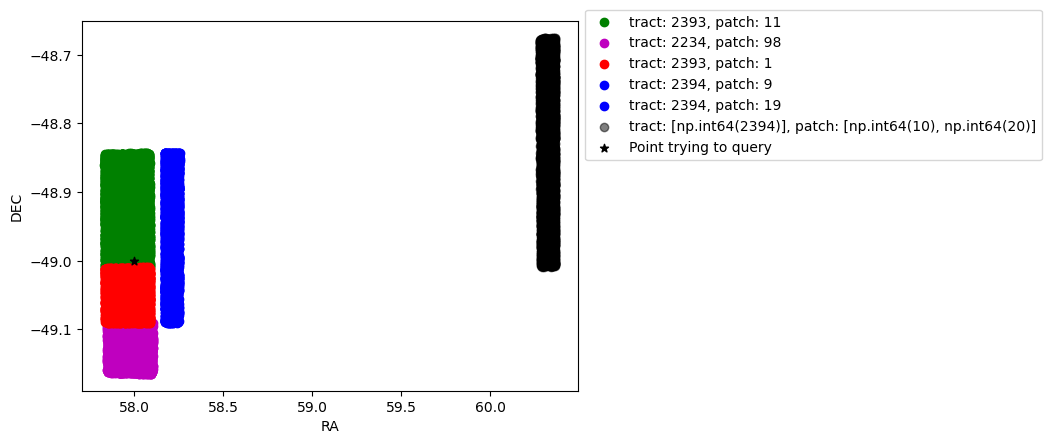

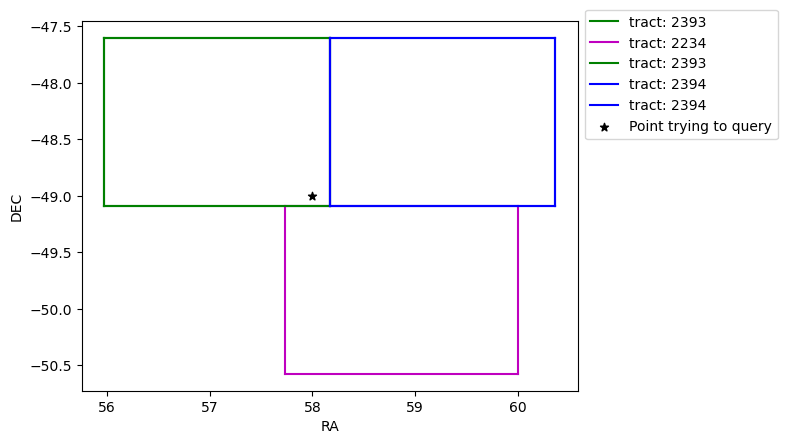

In [27]:
# plotting bc weirdness
tract = int(np.unique(dataset['tract']))
patch = int(np.unique(dataset['patch']))
plt.scatter(dataset['coord_ra'],dataset['coord_dec'],label=f'tract: {tract}, patch: {patch}', c='g')

for df in full_datasets:
    if int(np.unique(df['tract'])) == 2394:
        missing_tracts = df[(df['patch']==10) | (df['patch']==20)]

c = {2234 : 'm', 2393 : 'r', 2394 : 'b'}
for i in range(len(datasets)):
    tract = int(np.unique(datasets[i]['tract']))
    patch = int(np.unique(datasets[i]['patch']))
    plt.scatter(datasets[i]['coord_ra'],datasets[i]['coord_dec'],
                label=f'tract: {tract}, patch: {patch}', c=c[tract])
plt.scatter(missing_tracts['coord_ra'],missing_tracts['coord_dec'],
            label=f'tract: {list(np.unique(missing_tracts['tract']))}, patch: {list(np.unique(missing_tracts['patch']))}', 
            c='k',alpha = 0.5)

plt.xlabel('RA')
plt.ylabel('DEC')
#plt.xlim(58.3,57.8)
plt.scatter(ra,dec,label='Point trying to query', marker='*',c='k')
plt.legend(bbox_to_anchor=(1,1.05))
plt.show()

# plotting just the edges of the tracts
tract = int(np.unique(full_dataset['tract']))
#patch = np.unique(full_dataset['patch'])
min_ra, max_ra = np.min(full_dataset['coord_ra']),np.max(full_dataset['coord_ra'])
min_dec, max_dec = np.min(full_dataset['coord_dec']),np.max(full_dataset['coord_dec'])
plt.plot(np.linspace(min_ra,min_ra,5), np.linspace(min_dec,max_dec,5), c='g')
plt.plot(np.linspace(min_ra,max_ra,5), np.linspace(max_dec,max_dec,5), c='g')
plt.plot(np.linspace(max_ra,max_ra,5), np.linspace(max_dec,min_dec,5), c='g')
plt.plot(np.linspace(max_ra,min_ra,5), np.linspace(min_dec,min_dec,5),
            label=f'tract: {tract}', c='g')

c = {2234 : 'm', 2393 : 'g', 2394 : 'b'}
for i in range(len(full_datasets)):
    tract = int(np.unique(full_datasets[i]['tract']))
    #patch = np.unique(full_dataset['patch'])
    min_ra, max_ra = np.min(full_datasets[i]['coord_ra']),np.max(full_datasets[i]['coord_ra'])
    min_dec, max_dec = np.min(full_datasets[i]['coord_dec']),np.max(full_datasets[i]['coord_dec'])
    plt.plot(np.linspace(min_ra,min_ra,5), np.linspace(min_dec,max_dec,5), c=c[tract])
    plt.plot(np.linspace(min_ra,max_ra,5), np.linspace(max_dec,max_dec,5), c=c[tract])
    plt.plot(np.linspace(max_ra,max_ra,5), np.linspace(max_dec,min_dec,5), c=c[tract])
    plt.plot(np.linspace(max_ra,min_ra,5), np.linspace(min_dec,min_dec,5),
                label=f'tract: {tract}', c=c[tract])

plt.xlabel('RA')
plt.ylabel('DEC')
#plt.xlim(58.3,57.8)
plt.scatter(ra,dec,label='Point trying to query', marker='*',c='k')
plt.legend(bbox_to_anchor=(1,1.05))
plt.show()

I want to be able to call up a patch and get all the euclid data that overlaps with that. it might require feeding in the coordinates of the edges to the coordinate class. that would tell me that i should keep the coordinate query small  
I think for the euclid query for coord